Title

“Zomato Restaurant Data Analysis: Factors Affecting Ratings & Customer Engagement”

Problem Statement
What drives restaurant ratings?
Does cost influence ratings?
Does online delivery impact popularity?
Which cuisines and cities dominate?

Importing required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Data Understanding

In [4]:
data = pd.read_csv('zomato.csv',encoding='latin-1')

In [5]:
data.head(10)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229
5,18189371,Din Tai Fung,162,Mandaluyong City,"Ground Floor, Mega Fashion Hall, SM Megamall, ...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056314,14.583764,Chinese,...,Botswana Pula(P),No,No,No,No,3,4.4,Green,Very Good,336
6,6300781,Buffet 101,162,Pasay City,"Building K, SM By The Bay, Sunset Boulevard, M...","SM by the Bay, Mall of Asia Complex, Pasay City","SM by the Bay, Mall of Asia Complex, Pasay Cit...",120.979667,14.531333,"Asian, European",...,Botswana Pula(P),Yes,No,No,No,4,4.0,Green,Very Good,520
7,6301290,Vikings,162,Pasay City,"Building B, By The Bay, Seaside Boulevard, Mal...","SM by the Bay, Mall of Asia Complex, Pasay City","SM by the Bay, Mall of Asia Complex, Pasay Cit...",120.979333,14.540000,"Seafood, Filipino, Asian, European",...,Botswana Pula(P),Yes,No,No,No,4,4.2,Green,Very Good,677
8,6300010,Spiral - Sofitel Philippine Plaza Manila,162,Pasay City,"Plaza Level, Sofitel Philippine Plaza Manila, ...","Sofitel Philippine Plaza Manila, Pasay City","Sofitel Philippine Plaza Manila, Pasay City, P...",120.980090,14.552990,"European, Asian, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.9,Dark Green,Excellent,621
9,6314987,Locavore,162,Pasig City,"Brixton Technology Center, 10 Brixton Street, ...",Kapitolyo,"Kapitolyo, Pasig City",121.056532,14.572041,Filipino,...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,532


In [7]:
data.shape

(9551, 21)

In [8]:
data.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [10]:
data.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


Data Cleaning 

In [11]:
data.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [12]:
# Drop Null Values 
data.dropna(inplace=True)

In [13]:
# Checking null values
data.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [15]:
data.duplicated().sum()

0

In [21]:
data.drop(columns=['Address','Locality','Locality Verbose'],inplace=True)

Data Cleaning 
1. Checked Null Values 
2. Removed Null Values
3. Checked Duplicates 
4. Removed irrelavent Columns like - Address,Locality,Locality Verbose

Feature Engineering

In [17]:
data['Aggregate rating']

0       4.8
1       4.5
2       4.4
3       4.9
4       4.8
       ... 
9546    4.1
9547    4.2
9548    3.7
9549    4.0
9550    4.0
Name: Aggregate rating, Length: 9542, dtype: float64

In [18]:
def rating_category(x):
    if x >= 4:
        return "Excellent"
    elif x >= 3:
        return "Good"
    else:
        return "Poor"
data['Rating_category'] = data['Aggregate rating'].apply(rating_category)

In [44]:
data['cost_per_person'] =data['Average Cost for two'] / 2

data['is_expensive'] = data['Average Cost for two'].apply(lambda x: 1 if x > data['Average Cost for two'].mean() else 0)

In [45]:
data.head(5)

,Restaurant ID,Restaurant Name,Country Code,City,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,...,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Rating_category,cost_per_person,is_expensive
0,6317637,Le Petit Souffle,162,Makati City,121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,...,No,No,3,4.8,Dark Green,Excellent,314,Excellent,550.0,0
1,6304287,Izakaya Kikufuji,162,Makati City,121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,...,No,No,3,4.5,Dark Green,Excellent,591,Excellent,600.0,0
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,...,No,No,4,4.4,Green,Very Good,270,Excellent,2000.0,1
3,6318506,Ooma,162,Mandaluyong City,121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,...,No,No,4,4.9,Dark Green,Excellent,365,Excellent,750.0,1
4,6314302,Sambo Kojin,162,Mandaluyong City,121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,...,No,No,4,4.8,Dark Green,Excellent,229,Excellent,750.0,1


Join Country Code with thee Zomato dataset

In [23]:
country_df = pd.read_excel('Country-Code.xlsx')


In [24]:
country_df.head()

,Country Code,Country
0,1,India
1,14,Australia
2,30,Brazil
3,37,Canada
4,94,Indonesia


In [25]:
df = pd.merge(data,country_df,on='Country Code',how='left')

In [28]:
pd.unique(df['Country'])

array(['Phillipines', 'Brazil', 'United States', 'Australia', 'Canada',
       'Singapore', 'UAE', 'India', 'Indonesia', 'New Zealand',
       'United Kingdom', 'Qatar', 'South Africa', 'Sri Lanka', 'Turkey'],
      dtype=object)

Univariate Analysis

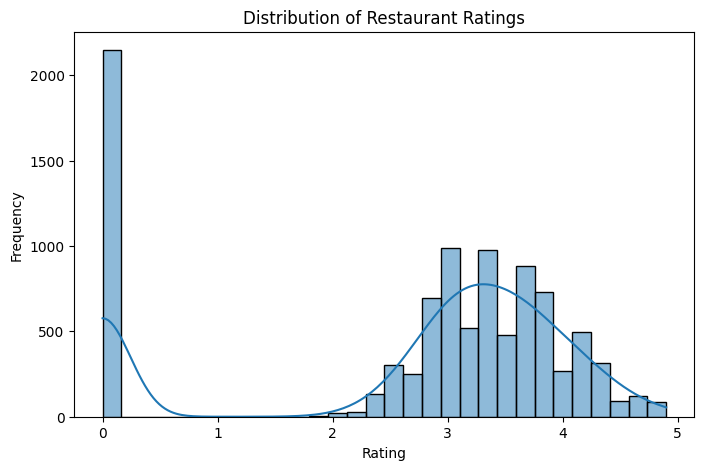

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(df['Aggregate rating'], bins=30, kde=True)

plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

Rating Distribution
This plot shows the distribution of restaurant ratings across the dataset.

**Insights:**
- Most restaurants have ratings between 2.5 and 4.5, indicating moderate to good customer satisfaction.
- A noticeable number of restaurants have a rating of 0, which may represent unrated or newly listed restaurants.
- The distribution is slightly left-skewed, suggesting that extremely high ratings are less common.

In [47]:
Country_names=df.Country.value_counts().index
Country_val=df.Country.value_counts().values

([<matplotlib.patches.Wedge at 0x1fefdbf89b0>,
 [Text(-1.083531565863807, 0.189629496061996, 'India'),
  Text(1.0779194567879458, -0.21929351262173782, 'United States'),
  Text(1.0995857034695016, -0.03018742661244155, 'United Kingdom')],
 [Text(-0.5910172177438947, 0.10343427057927053, '94.49%'),
  Text(0.5879560673388794, -0.1196146432482206, '4.64%'),
  Text(0.5997740200742735, -0.016465869061331753, '0.87%')])

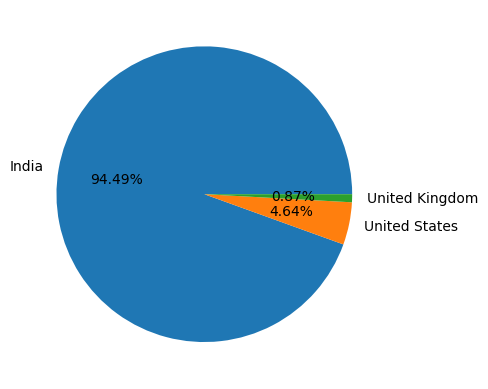

In [48]:
plt.pie(Country_val[:3],labels=Country_names[:3],autopct='%1.2f%%')

**Insights:**
India as more number of customers of zomato
US is second country with 4.73% 
UK is third country with 0.87% 

Votes Distribution

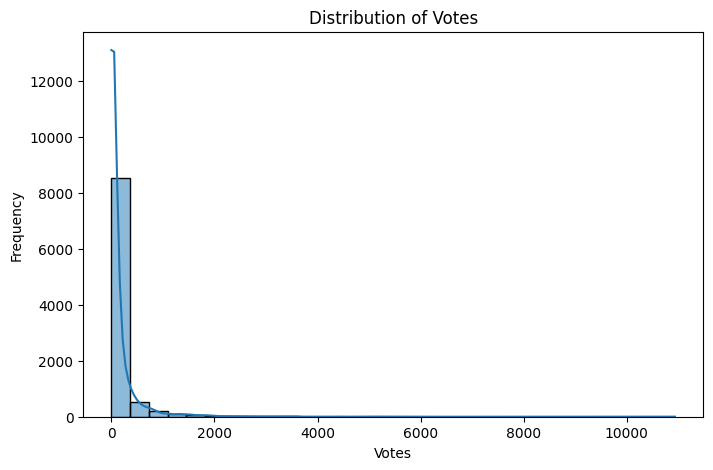

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(df['Votes'], bins=30, kde=True)

plt.title("Distribution of Votes")
plt.xlabel("Votes")
plt.ylabel("Frequency")
plt.show()

### Votes Distribution

This plot represents how many votes (customer engagement) restaurants receive.

**Insights:**
- Most restaurants have very low vote counts.
- A small number of restaurants receive significantly higher votes, indicating popularity concentration.
- The distribution is highly right-skewed.

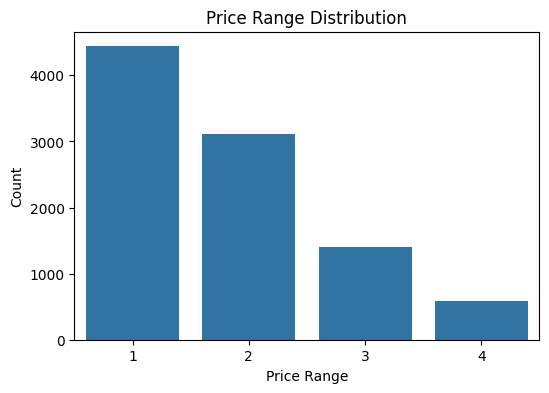

In [31]:
plt.figure(figsize=(6,4))
sns.countplot(x='Price range', data=df)

plt.title("Price Range Distribution")
plt.xlabel("Price Range")
plt.ylabel("Count")
plt.show()

### Price Range Distribution

This chart shows the distribution of restaurants across different price categories.

**Insights:**
- The majority of restaurants fall into lower price ranges.
- High-end restaurants are fewer in number.

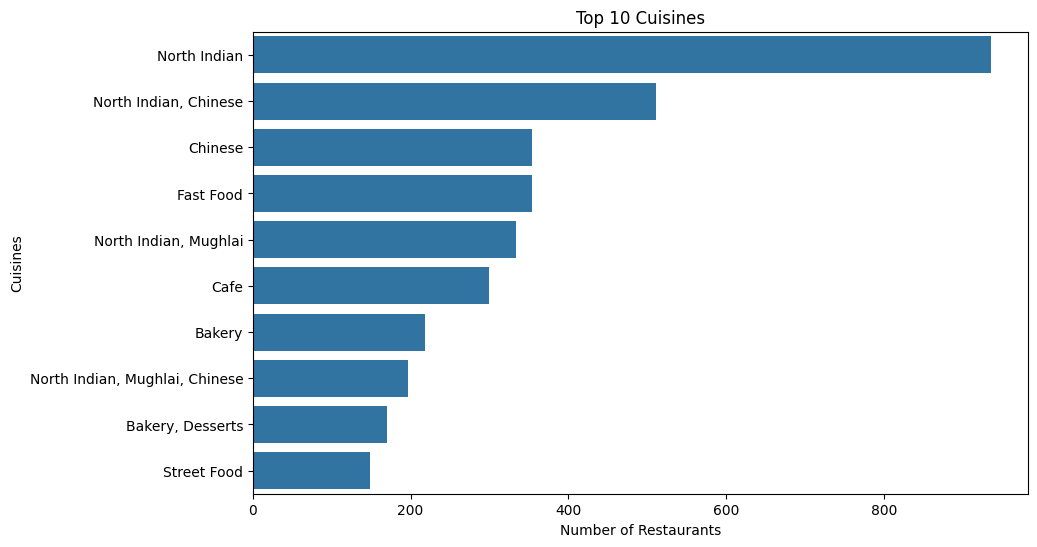

In [32]:
top_cuisines = df['Cuisines'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index)

plt.title("Top 10 Cuisines")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisines")
plt.show()

### Top 10 Cuisines
This analysis identifies the most common cuisines offered by restaurants.

**Insights:**
- The North Indian Cuisines dominates in the Cuisines list
- There is a concentration of restaurants offering similar cuisine types.


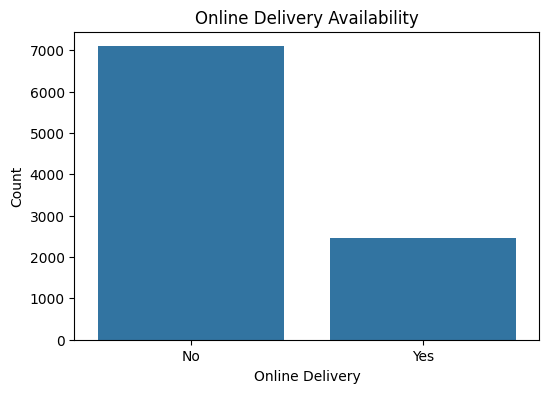

In [37]:
plt.figure(figsize=(6,4))
sns.countplot(x='Has Online delivery', data=df)

plt.title("Online Delivery Availability")
plt.xlabel("Online Delivery")
plt.ylabel("Count")
plt.show()

### Online Delivery Availability

This plot shows whether restaurants provide online delivery services.

**Insights:**
- A significant number of restaurants do not offer online delivery.
- However, a notable portion does provide this service.

Bivariate Analysis

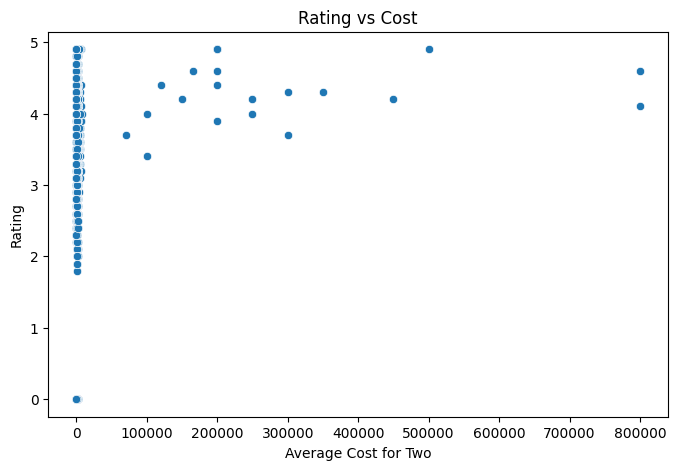

In [39]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Average Cost for two', y='Aggregate rating', data=df)

plt.title("Rating vs Cost")
plt.xlabel("Average Cost for Two")
plt.ylabel("Rating")
plt.show()

### Rating vs Cost

This analysis explores the relationship between restaurant pricing and customer ratings.

**Insights:**
- There is no strong linear relationship between cost and rating.
- Both low-cost and high-cost restaurants can achieve high ratings.
- Some high-cost restaurants have lower ratings, indicating that price does not guarantee quality.

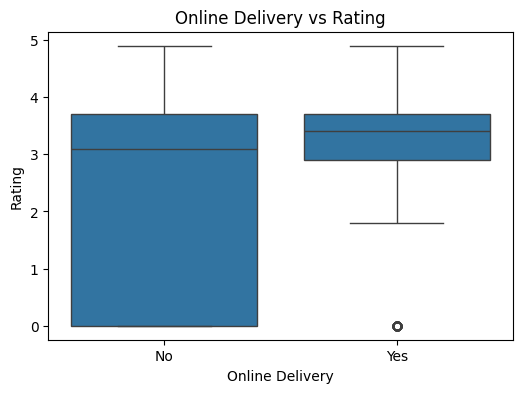

In [40]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Has Online delivery', y='Aggregate rating', data=df)

plt.title("Online Delivery vs Rating")
plt.xlabel("Online Delivery")
plt.ylabel("Rating")
plt.show()

### Online Delivery vs Rating

This plot compares ratings of restaurants with and without online delivery.

**Insights:**
- Restaurants offering online delivery tend to have slightly higher median ratings.
- Variability in ratings is present in both categories.

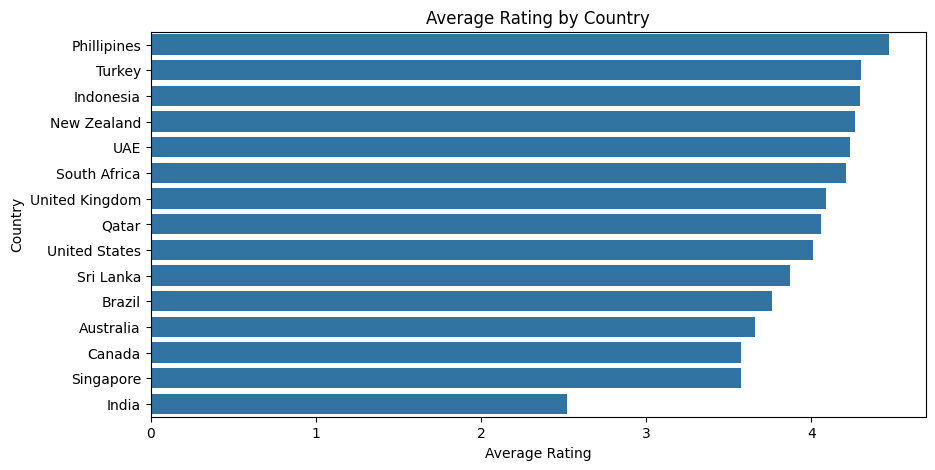

In [41]:
country_rating = df.groupby('Country')['Aggregate rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=country_rating.values, y=country_rating.index)

plt.title("Average Rating by Country")
plt.xlabel("Average Rating")
plt.ylabel("Country")
plt.show()

### Country vs Rating

This analysis compares average ratings across different countries.

**Insights:**
- Some countries have higher average ratings than others.
- Differences may be due to customer expectations, culture, or data distribution.

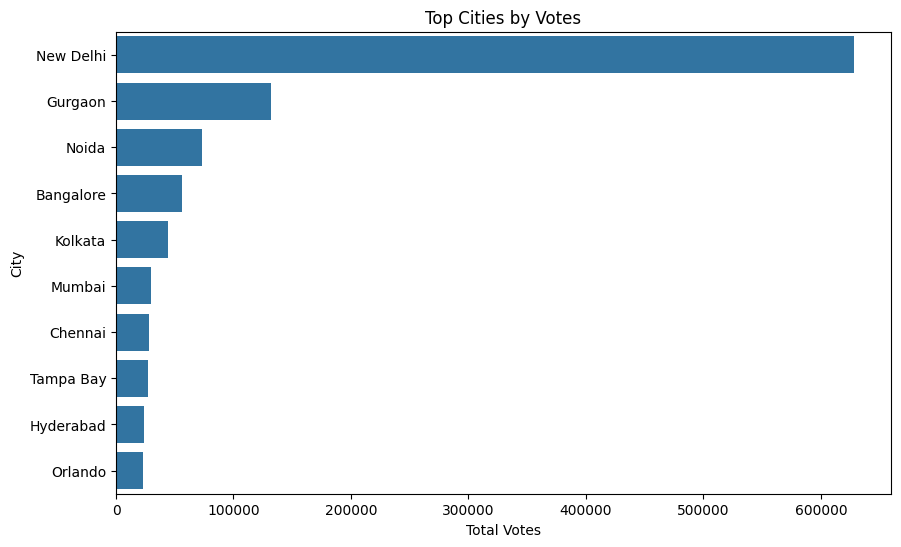

In [42]:
top_city_votes = df.groupby('City')['Votes'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_city_votes.values, y=top_city_votes.index)

plt.title("Top Cities by Votes")
plt.xlabel("Total Votes")
plt.ylabel("City")
plt.show()

### City vs Votes

This chart highlights cities with the highest customer engagement.

**Insights:**
- New Delhi dominates total votes around 600k
- High engagement indicates active users and popular restaurants.

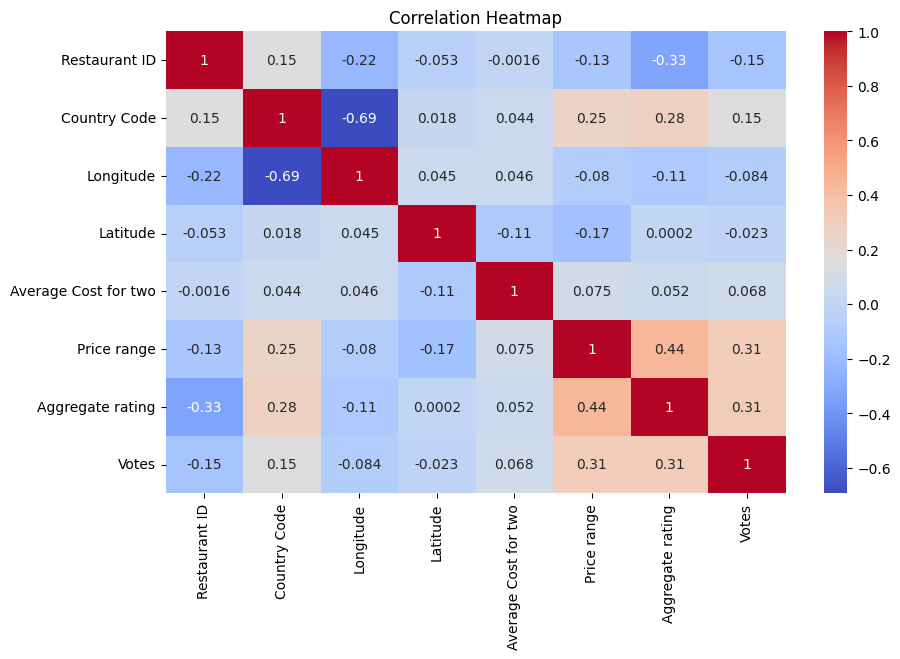

In [43]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

## Key Insights

1. Most restaurants fall in mid-rating range → competition is high
2. Online delivery increases engagement (votes)
3. Price does not strongly determine rating
4. Dataset heavily biased toward India
5. Few restaurants dominate customer attention

## Business Recommendations

1. Restaurants should enable online delivery to increase reach
2. Focus on customer experience rather than pricing alone
3. Mid-range pricing strategy is optimal
4. Encourage customer reviews to increase engagement

## Conclusion

The analysis shows that most restaurants have average ratings, indicating high competition. Pricing does not strongly impact ratings, while features like online delivery improve customer engagement. A few restaurants receive most of the attention, and the dataset is largely dominated by India.

Overall, customer experience and convenience play a more important role than price in determining restaurant success.